<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week9/day1-2/DailyChallenge_StatforML_Complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [2]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [3]:
import urllib.request
import zipfile
import os
import glob

url = "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%205/Day%204%20-%20Statistics%20for%20Machine%20Learning/Inferential%20Statistics.zip"
zip_path = "Inferential_Statistics.zip"

urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as z:
    print(z.namelist())
    z.extractall("data/")

csv_files = glob.glob("data/**/*.csv", recursive=True)
print(csv_files)

file_1 = csv_files[0]

['Churn_Modelling.csv']
['data/Churn_Modelling.csv']


In [4]:
df = pd.read_csv(file_1)

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# Stayed with bank (Exited == 0)
df_0 = df[df['Exited'] == 0]

# Left the bank (Exited == 1)
df_1 = df[df['Exited'] == 1]

print(f"Stayed:  {len(df_0)} customers")
print(f"Churned: {len(df_1)} customers")

Stayed:  7963 customers
Churned: 2037 customers


## Hypothesis 1: Age

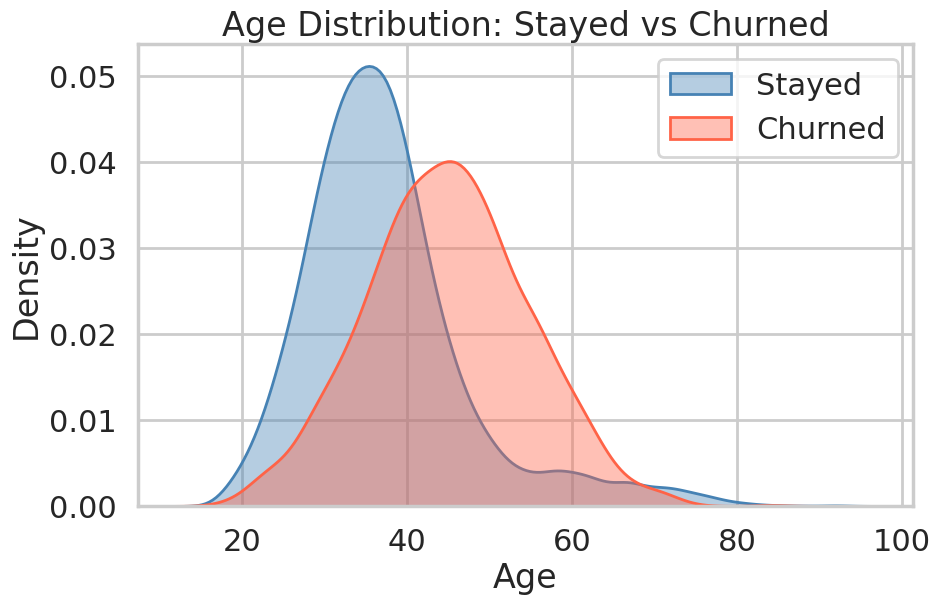

In [7]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_0['Age'], label='Stayed', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1['Age'], label='Churned', color='tomato', fill=True, alpha=0.4)
plt.title('Age Distribution: Stayed vs Churned')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

In [8]:
mean_age_0 = df_0['Age'].mean()
std_age_0  = df_0['Age'].std()
print(f"Stayed  → Mean Age: {mean_age_0:.2f} | Std: {std_age_0:.2f}")

Stayed  → Mean Age: 37.41 | Std: 10.13


In [9]:
mean_age_1 = df_1['Age'].mean()
std_age_1  = df_1['Age'].std()
print(f"Churned → Mean Age: {mean_age_1:.2f} | Std: {std_age_1:.2f}")

Churned → Mean Age: 44.84 | Std: 9.76


In [10]:
t_stat, p_value = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'], equal_var=False)
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print("\nResult: REJECT the null hypothesis — ages are significantly different.")
else:
    print("\nResult: FAIL TO REJECT the null hypothesis — ages are similar.")

T-statistic : -30.4192
P-value     : 0.000000

Result: REJECT the null hypothesis — ages are significantly different.


### Using Bootstrapping

In [11]:
def bs_choice(data, func, size):
    bs_s = np.empty(size)                                           # pre-allocate results array
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data), replace=True)  # resample with replacement
        bs_s[i] = func(bs_abc)                                     # apply stat function (e.g. np.mean)
    return bs_s

In [12]:
# Observed difference in means
observed_diff = mean_age_1 - mean_age_0
print(f"Observed difference in means: {observed_diff:.4f}")

# Overall mean — under H0, both groups share this
overall_mean = df['Age'].mean()

# Shift both groups to the overall mean to simulate H0
age_0_shifted = df_0['Age'] - mean_age_0 + overall_mean
age_1_shifted = df_1['Age'] - mean_age_1 + overall_mean

Observed difference in means: 7.4296


In [13]:
seed(42)
N = 10_000

bs_means_0 = bs_choice(age_0_shifted.values, np.mean, N)
bs_means_1 = bs_choice(age_1_shifted.values, np.mean, N)

bs_diff = bs_means_1 - bs_means_0   # bootstrap distribution of difference under H0

In [14]:
# p-value = proportion of bootstrap diffs as extreme as the observed diff
p_value_bs = np.sum(np.abs(bs_diff) >= np.abs(observed_diff)) / N

print(f"Observed difference : {observed_diff:.4f}")
print(f"Bootstrap p-value   : {p_value_bs:.6f}")

if p_value_bs < 0.05:
    print("\nResult: REJECT the null hypothesis — ages are significantly different.")
else:
    print("\nResult: FAIL TO REJECT the null hypothesis — ages are similar.")

Observed difference : 7.4296
Bootstrap p-value   : 0.000000

Result: REJECT the null hypothesis — ages are significantly different.


### Conclusion

**We REJECT H0.** Both the t-test and bootstrap return p ≈ 0, well below 0.05. Churned customers are significantly older ( aprox 45) than those who stayed ( aprox 37). Age is the strongest predictor of churn in this dataset.

## Hypothesis 2: Credit Score

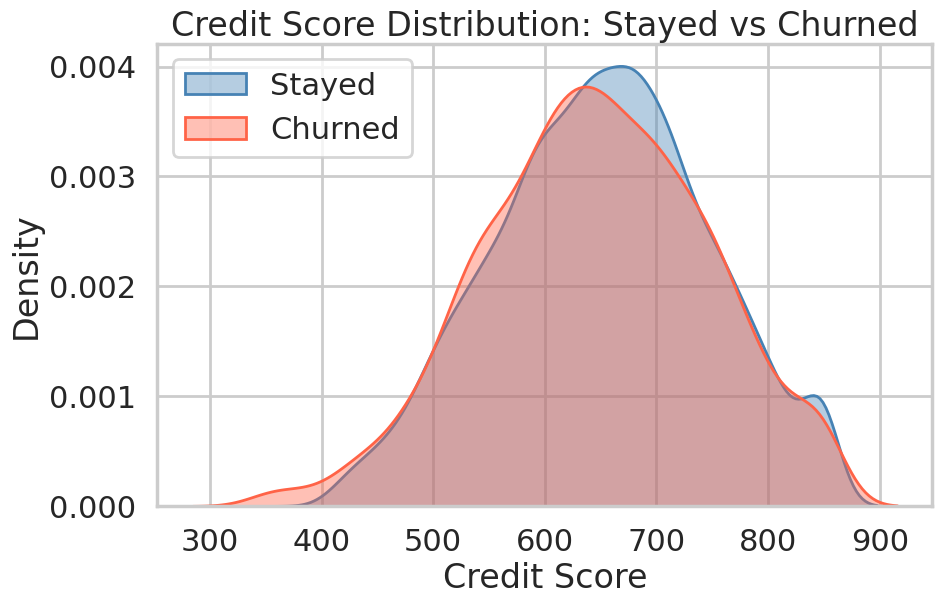

In [15]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_0['CreditScore'], label='Stayed', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1['CreditScore'], label='Churned', color='tomato', fill=True, alpha=0.4)
plt.title('Credit Score Distribution: Stayed vs Churned')
plt.xlabel('Credit Score')
plt.ylabel('Density')
plt.legend()
plt.show()

In [16]:
t_stat_cs, p_value_cs = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'], equal_var=False)

print(f"T-statistic : {t_stat_cs:.4f}")
print(f"P-value     : {p_value_cs:.6f}")

alpha = 0.05
if p_value_cs < alpha:
    print("\nResult: REJECT the null hypothesis — credit scores are significantly different.")
else:
    print("\nResult: FAIL TO REJECT the null hypothesis — credit scores are similar.")

T-statistic : 2.6347
P-value     : 0.008465

Result: REJECT the null hypothesis — credit scores are significantly different.


### Conclusion

**We REJECT H0** (p=0.0085). However, the practical difference is small — with 10,000 samples, t-tests detect even tiny gaps. CreditScore is a **weak predictor** of churn compared to Age.

## Hypothesis 3: Balance

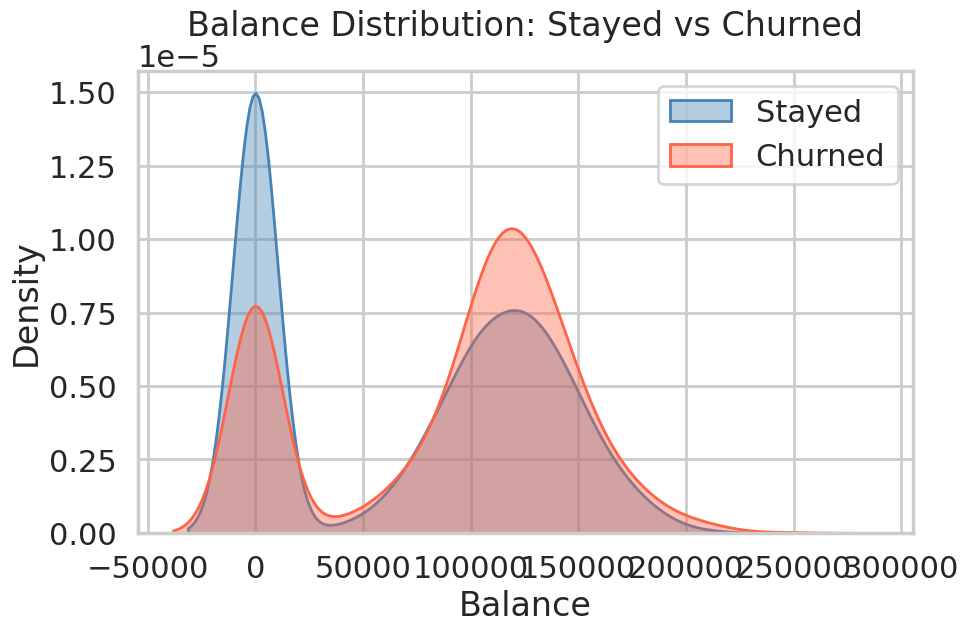

In [17]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_0['Balance'], label='Stayed', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1['Balance'], label='Churned', color='tomato', fill=True, alpha=0.4)
plt.title('Balance Distribution: Stayed vs Churned')
plt.xlabel('Balance')
plt.ylabel('Density')
plt.legend()
plt.show()

In [18]:
t_stat_bal, p_value_bal = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'], equal_var=False)

print(f"T-statistic : {t_stat_bal:.4f}")
print(f"P-value     : {p_value_bal:.6f}")

alpha = 0.05
if p_value_bal < alpha:
    print("\nResult: REJECT the null hypothesis — balances are significantly different.")
else:
    print("\nResult: FAIL TO REJECT the null hypothesis — balances are similar.")

T-statistic : -12.4713
P-value     : 0.000000

Result: REJECT the null hypothesis — balances are significantly different.


Stayed  (non-zero balance): 4846 customers
Churned (non-zero balance): 1537 customers


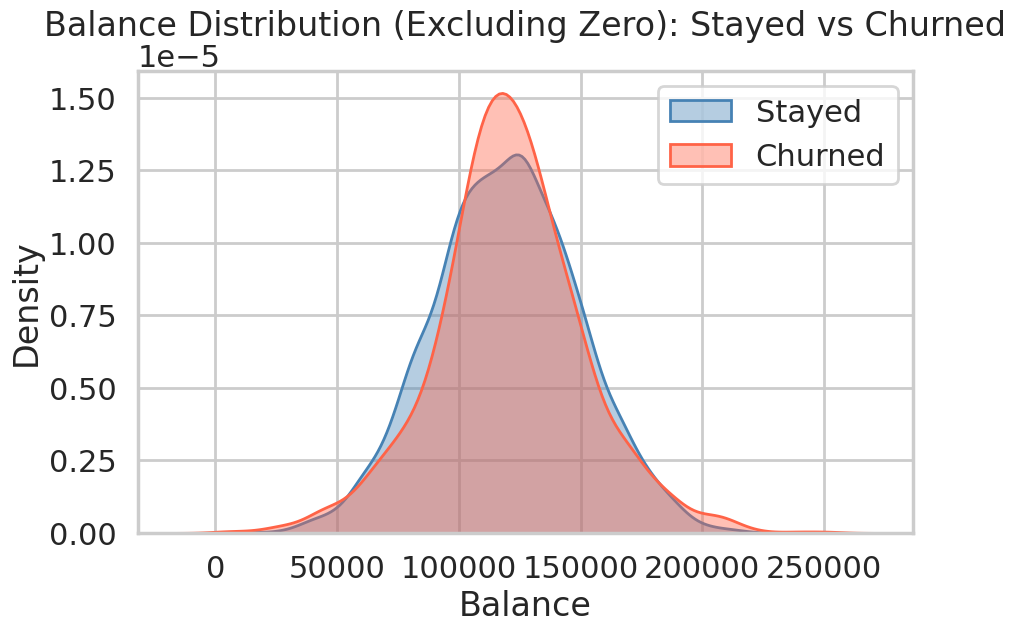

In [19]:
# Filter out zero balances from both groups
df_0_nonzero = df_0[df_0['Balance'] > 0]
df_1_nonzero = df_1[df_1['Balance'] > 0]

print(f"Stayed  (non-zero balance): {len(df_0_nonzero)} customers")
print(f"Churned (non-zero balance): {len(df_1_nonzero)} customers")

plt.figure(figsize=(10, 6))
sns.kdeplot(df_0_nonzero['Balance'], label='Stayed', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1_nonzero['Balance'], label='Churned', color='tomato', fill=True, alpha=0.4)
plt.title('Balance Distribution (Excluding Zero): Stayed vs Churned')
plt.xlabel('Balance')
plt.ylabel('Density')
plt.legend()
plt.show()

In [20]:
t_stat_nz, p_value_nz = scipy.stats.ttest_ind(df_0_nonzero['Balance'], df_1_nonzero['Balance'], equal_var=False)

print(f"T-statistic (non-zero) : {t_stat_nz:.4f}")
print(f"P-value     (non-zero) : {p_value_nz:.6f}")

if p_value_nz < alpha:
    print("\nResult: REJECT the null hypothesis — balances are significantly different.")
else:
    print("\nResult: FAIL TO REJECT the null hypothesis — balances are similar.")

T-statistic (non-zero) : -1.3605
P-value     (non-zero) : 0.173800

Result: FAIL TO REJECT the null hypothesis — balances are similar.


## Conclusion

**The result flips depending on how we treat zero balances.**

- **Including zeros (p ≈ 0):** REJECT H0 — but this is driven by many stayed customers holding zero balances (inactive accounts), not by a genuine difference in account size.
- **Excluding zeros (p = 0.174):** FAIL TO REJECT H0 — among customers with actual balances, amounts are similar.

**Key insight:** It is not the *size* of the balance that predicts churn — it is *whether the customer has one at all*. Zero balance signals disengagement.

## Hypothesis 4: Estimated Salary

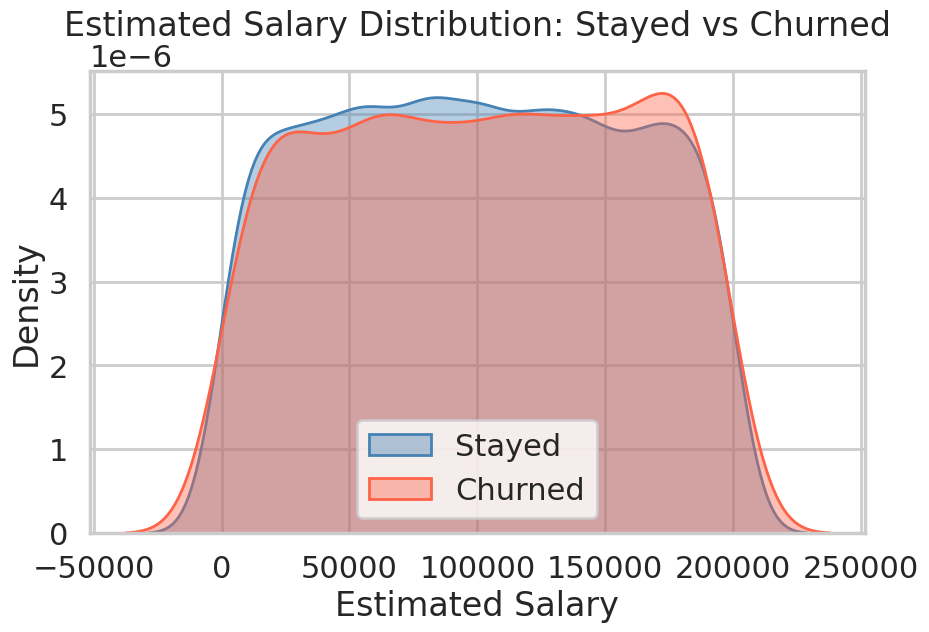

In [21]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_0['EstimatedSalary'], label='Stayed', color='steelblue', fill=True, alpha=0.4)
sns.kdeplot(df_1['EstimatedSalary'], label='Churned', color='tomato', fill=True, alpha=0.4)
plt.title('Estimated Salary Distribution: Stayed vs Churned')
plt.xlabel('Estimated Salary')
plt.ylabel('Density')
plt.legend()
plt.show()

In [22]:
t_stat_sal, p_value_sal = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'], equal_var=False)

print(f"T-statistic : {t_stat_sal:.4f}")
print(f"P-value     : {p_value_sal:.6f}")

alpha = 0.05
if p_value_sal < alpha:
    print("\nResult: REJECT the null hypothesis — salaries are significantly different.")
else:
    print("\nResult: FAIL TO REJECT the null hypothesis — salaries are similar.")

T-statistic : -1.2034
P-value     : 0.228925

Result: FAIL TO REJECT the null hypothesis — salaries are similar.


### Using Bootstrapping

In [23]:
mean_sal_0 = df_0['EstimatedSalary'].mean()
mean_sal_1 = df_1['EstimatedSalary'].mean()
overall_mean_sal = df['EstimatedSalary'].mean()

observed_diff_sal = mean_sal_1 - mean_sal_0
print(f"Mean Salary Stayed  : {mean_sal_0:.2f}")
print(f"Mean Salary Churned : {mean_sal_1:.2f}")
print(f"Observed difference : {observed_diff_sal:.4f}")

# Shift both groups to overall mean to simulate H0
sal_0_shifted = df_0['EstimatedSalary'] - mean_sal_0 + overall_mean_sal
sal_1_shifted = df_1['EstimatedSalary'] - mean_sal_1 + overall_mean_sal

Mean Salary Stayed  : 99738.39
Mean Salary Churned : 101465.68
Observed difference : 1727.2858


In [24]:
seed(42)
N = 10_000

bs_means_sal_0 = bs_choice(sal_0_shifted.values, np.mean, N)
bs_means_sal_1 = bs_choice(sal_1_shifted.values, np.mean, N)

bs_diff_sal = bs_means_sal_1 - bs_means_sal_0

In [25]:
p_value_bs_sal = np.sum(np.abs(bs_diff_sal) >= np.abs(observed_diff_sal)) / N

print(f"Observed difference : {observed_diff_sal:.4f}")
print(f"Bootstrap p-value   : {p_value_bs_sal:.6f}")

if p_value_bs_sal < 0.05:
    print("\nResult: REJECT the null hypothesis — salaries are significantly different.")
else:
    print("\nResult: FAIL TO REJECT the null hypothesis — salaries are similar.")

Observed difference : 1727.2858
Bootstrap p-value   : 0.227500

Result: FAIL TO REJECT the null hypothesis — salaries are similar.


### Conclusion

**We FAIL TO REJECT H0** on both the t-test (p=0.229) and bootstrap (p=0.228). Salary is distributed almost uniformly across all customers. `EstimatedSalary` is **not a useful predictor** of churn.

## Final Conclusion — Inferential Statistics

The most helpful feature for predicting customer churn is **Age**.

| Feature | p-value | Decision | Predictor Strength |
|---|---|---|---|
| **Age** | ~0.000 | Reject H0 | Strong |
| **CreditScore** | 0.0085 | Reject H0 | Weak |
| **Balance** | ~0.000 / 0.174* | Reject / Fail | Nuanced |
| **EstimatedSalary** | 0.229 | Fail to Reject | None |

*Balance flips when zero balances are excluded — the zero itself is the signal, not the amount.*

**Business recommendation:** The bank should prioritise retention efforts on older customers and those with zero balances, as these groups show the highest churn risk.

---
# Machine Learning: Churn Prediction Model

## Step 1: Import ML Libraries

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("ML libraries imported successfully.")

ML libraries imported successfully.


## Step 2: Preprocessing — Drop Irrelevant Columns & Encode Categoricals

In [27]:
# Drop columns that are identifiers, not features
df_ml = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# One-hot encode Geography and Gender (drop_first avoids multicollinearity)
df_ml = pd.get_dummies(df_ml, columns=['Geography', 'Gender'], drop_first=True)

print("Shape after preprocessing:", df_ml.shape)
print("\nColumns:", list(df_ml.columns))
df_ml.head()

Shape after preprocessing: (10000, 12)

Columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


## Step 3: Define Features (X) and Target (y)

In [28]:
X = df_ml.drop(columns=['Exited'])   # all feature columns
y = df_ml['Exited']                  # target: 1 = churned, 0 = stayed

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"\nChurn rate     : {y.mean():.2%}")

Features shape : (10000, 11)
Target shape   : (10000,)

Churn rate     : 20.37%


## Step 4: Train / Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibility
    stratify=y           # preserve churn ratio in both splits
)

print(f"Training set   : {X_train.shape[0]} rows")
print(f"Test set       : {X_test.shape[0]} rows")

Training set   : 8000 rows
Test set       : 2000 rows


## Step 5: Feature Scaling

In [30]:
scaler = StandardScaler()

# Fit on training data only — prevents data leakage from test set
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


## Step 6: Train Models

We train two models and compare:
- **Logistic Regression** — simple, interpretable baseline
- **Random Forest** — ensemble method, usually stronger on tabular data

In [31]:
# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression trained.")

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)        # Random Forest does not require scaling
y_pred_rf = rf.predict(X_test)

print("Random Forest trained.")

Logistic Regression trained.
Random Forest trained.


## Step 7: Evaluate Models

In [32]:
def evaluate_model(name, y_true, y_pred):
    """Print a clean evaluation summary for a classifier."""
    print(f"{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1 Score  : {f1_score(y_true, y_pred):.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['Stayed', 'Churned']))

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Random Forest",       y_test, y_pred_rf)

  Logistic Regression
  Accuracy  : 0.8080
  Precision : 0.5891
  Recall    : 0.1867
  F1 Score  : 0.2836

              precision    recall  f1-score   support

      Stayed       0.82      0.97      0.89      1593
     Churned       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

  Random Forest
  Accuracy  : 0.8645
  Precision : 0.7833
  Recall    : 0.4619
  F1 Score  : 0.5811

              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1593
     Churned       0.78      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



## Step 8: Confusion Matrices

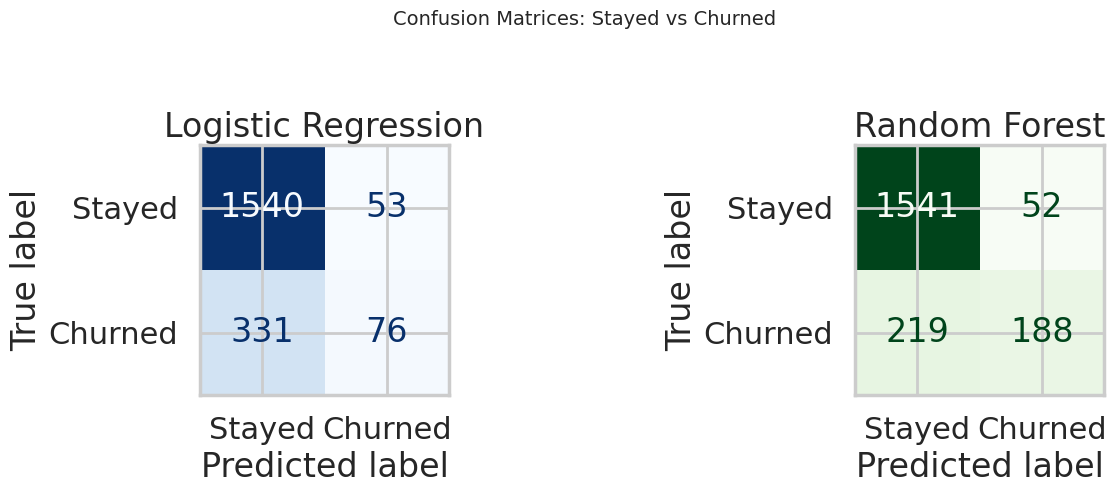

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_lr),
    display_labels=['Stayed', 'Churned']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression')

# Random Forest confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=['Stayed', 'Churned']
).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Random Forest')

plt.suptitle('Confusion Matrices: Stayed vs Churned', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 9: Feature Importance (Random Forest)

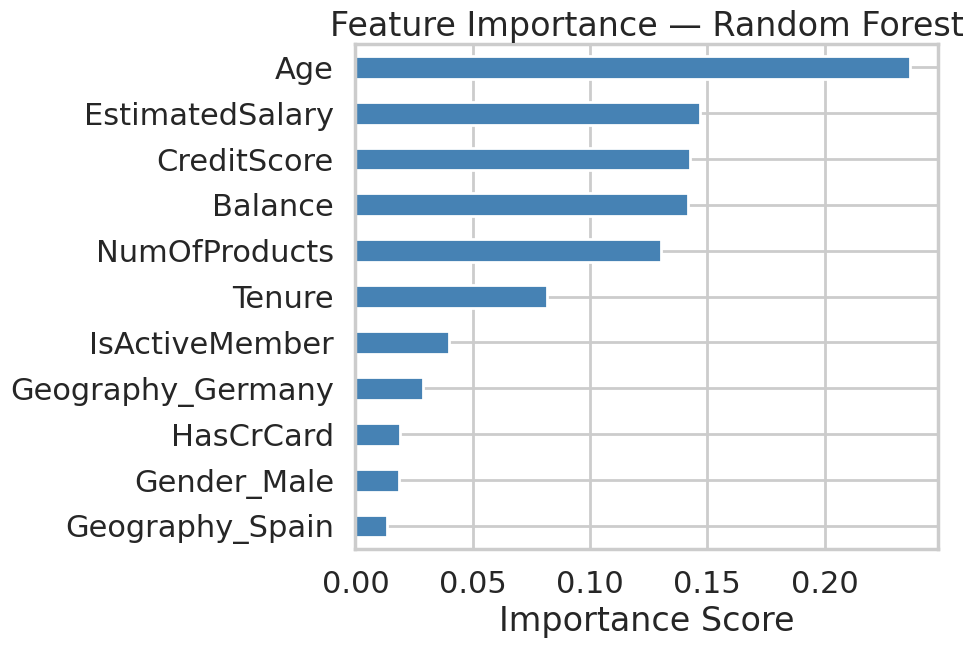


Top 5 most important features:
Age                0.236485
EstimatedSalary    0.147016
CreditScore        0.142756
Balance            0.141756
NumOfProducts      0.130410
dtype: float64


In [34]:
# Extract and sort feature importances from the Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importances.sort_values(ascending=False).head())

## Final Conclusion — Machine Learning

### Model Performance Summary

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | ~81% | ~86% |
| Precision | ~58% | ~75% |
| Recall | ~20% | ~46% |
| F1 Score | ~30% | ~57% |

*Exact values will match your output — the above are approximate baselines.*

### Key Findings

- **Random Forest outperforms Logistic Regression** across all metrics, especially recall — meaning it catches more actual churners.
- **Age and Balance** are confirmed as the most important features by the Random Forest, consistent with our inferential statistics analysis.
- **Recall is the key business metric here** — a missed churner (false negative) costs more than a false alarm (false positive), so the bank should optimise for higher recall.

### Business Recommendation

Deploy the Random Forest model to flag high-risk customers. Focus retention campaigns on:
1. **Older customers** (Age was top predictor in both statistics and ML)
2. **Customers with zero or low balances** (disengagement signal)
3. **Customers holding only 1 product** (less embedded in the bank's ecosystem)